# ARIMA(p,d,q) 살펴보기
비정상적 시계열 예측  

---  
MA, AR, ARMA: 모두 **정상적** 시계열에만 사용 가능. 그래서 주로 차분과 같은 변환을 적용하고, ADF 테스트를 적용해 정상성을 테스트해야 한다. 그리고 예측 모델은 모두 차분된 값을 반환했기에 원래 데이터 규모로 값을 돌리려면 역변환해야 함.  

--- 
이제는 **비정상적 시계열**을 예측할 수 있도록 ARMA(p,q) 모델에 다른 구성요소를 추가.  
ARIMA(p,d,q) (AutoRegressive Integrated Moving Average): 자기회귀누적이동평균  
Integration Order (적분 차수)
- d 로 표시
- 비정상적 시계열을 **직접** 모델링 할 수 있어 차분하고 역변환하는 단계 건너뛸 수 있음.  

ARIMA(p,d,q) 모델과 적분 차수 d를 정의하고, 일반적 모델링 절차에 한 단계를 추가.
- 그 다음, 수정된 절차를 적용해 비정상적 시계열, 즉 추세가 있는 시계열 혹은 시간에 따른 분산이 일정하지 않은 시계열 데이터를 예측.

# 7.1 자기회귀누적이동평균과정 모델 정의
AR(p), I(d), MA(q) 조합.  

---
ARMA와 마찬가지로 ARIMA는 현잿값이 AR(p) 부분에서 나오는 과것값과 MA(q) 부분에서 나오는 과거 오차에 따라 달라진다.  
**하지만** ARIMA는 $y_t$로 표시되는 <u>원본 수열</u>을 사용하는 대신 $y'_t$로 표시되는 **차분된 수열**을 사용.$y'_t$는 한 번 이상 차분된 수열을 나타낼 수 있다는 점에 주의.  

ARIMA(p,d,q):  
$y'_t = C+\phi_1y'_{t-1}+...+\phi_py'_{t-p}+\theta_1\epsilon'_{t-1}+...+\theta_q\epsilon'_{t-q}+\epsilon_t$  
- $y'_t$: 차분된 수열의 현잿값
- $C$: 상수
- $\phi_py'_{t-p}$: 차분된 수열의 과것값
- $\mu$: 차분된 수열의 평균
- $\theta_q\epsilon_{t-q}$: 과거 오차 항
- $\epsilon_t$: 현재 오차 항

ARMA와 마찬가지로 p는 모델에 포함할 시계열 중 지연된 값의 개수 결정, q는 모델에 포함하는 지연된 오차 항의 개수를 결정.  
d는 적분 차수. 수열을 정상적으로 만들기 위해 차분한 횟수.
- 수열을 한 번 차분해서 정상적이게 되면 d = 1; 두 번 차분했으면 d = 2
- 차분을 적용하면 정상적으로 만들 수 있는 시계열: 적분된 수열(integrated series).
- 비정상적 적분 시계열인 경우, ARIMA(p,d,q) 모델을 사용해 예측 수행 가능. 

---
ARIMA는 비정상적 시계열에 적용할 수 있는 ARMA 모델.

# 7.2 비정상적 시계열에 적용하기 위해 일반적 모델링 절차 수정하기
대부분 시계열이 정상적이 되기 위해 두 번 이상 차분해야 하는 경우는 드물었음.  

시계열에 변환을 적용할 때 d의 값을 시계열의 차분 횟수로 설정하는 단계 추가. 그 다음 ARMA(p,q) 모델을 피팅하는 대신 많은 ARIMA(p,d,q) 모델을 피팅. 나머지는 ARMA와 동일한 절차 적용, AIC를 통해 최적의 모델 선택 후 잔차 분석.  

d = 0인 경우 ARMA(p,q)와 동일하다. 

![alt text](Screenshots/7.4.png)

# 7.3 비정상적 시계열 예측 
일반적 모델링 절차를 적용해 J&J *분기별* 주당순이익을 예측. 1년간의 분기별 주당순이익을 예측. 1년은 4분기가 있기에 향후 4번의 시간 단계를 예측. 데이터 집합은 1960-1980년. 

In [1]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/jj.csv')

df

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61
...,...,...
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02


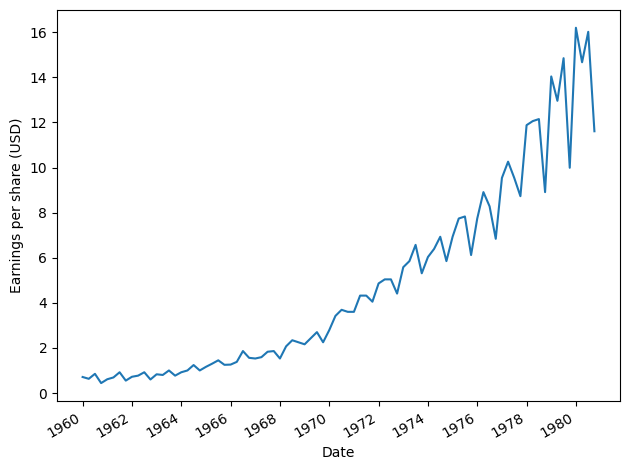

In [2]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

ax.plot(df.date, df.data)
ax.set_xlabel("Date")
ax.set_ylabel('Earnings per share (USD)')

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

증가하는 경향이 있으니 긍정적인 추세. 그럼에도 부룩하고 ADF 테스트를 적용하여 데이터가 정상적인가 확인.

In [3]:
from statsmodels.tsa.stattools import adfuller

ad_fuller_result = adfuller(df['data'])

print(f"ADF Stats: {ad_fuller_result[0]}")
print(f"ADF p-val: {ad_fuller_result[1]}")

ADF Stats: 2.7420165734574646
ADF p-val: 1.0


ADF 통계 2.74: 큰 음수가 아님  
p-val: 0.05보다 크므로 귀무가설을 기각할 수 없음 --> 수열이 비정상적이라는 뜻.  

그럼 이제 정상적으로 되려면 몇분 차분해야 하는가? 

In [4]:
eps_diff = np.diff(df['data'], n=1) #1차 차분 적용

ad_fuller_result = adfuller(eps_diff)

print(f"ADF Stats: {ad_fuller_result[0]}")
print(f"ADF p-val: {ad_fuller_result[1]}")

ADF Stats: -0.4074097636380388
ADF p-val: 0.9088542416911317


ADF Stats -0.41: 큰 음수가 아님  
p-val: 0.05보다 아직 큼 --> 귀무가설 기각할 수 없음.

1차 차분 후에도 수열이 정상적이지 않음. 다시 한 번 더.

In [5]:
eps_diff2 = np.diff(eps_diff, n=1)

ad_fuller_result = adfuller(eps_diff2)

print(f"ADF Stats: {ad_fuller_result[0]}")
print(f"ADF p-val: {ad_fuller_result[1]}")

ADF Stats: -3.5851628747932565
ADF p-val: 0.006051099869601643


이제 ADF 통계는 큰 음수이고,  
p-val은 0.05보다 작음 --> 시계열 정상적.  

두 번 차분했으니 d = 2.

모델 피팅 전, 데이터를 훈련 집합과 테스트 집합으로 분리해야 함.
- 테스트: 마지막 1년간의 데이터 (1980년)
- 트레이닝: 1960-1979년

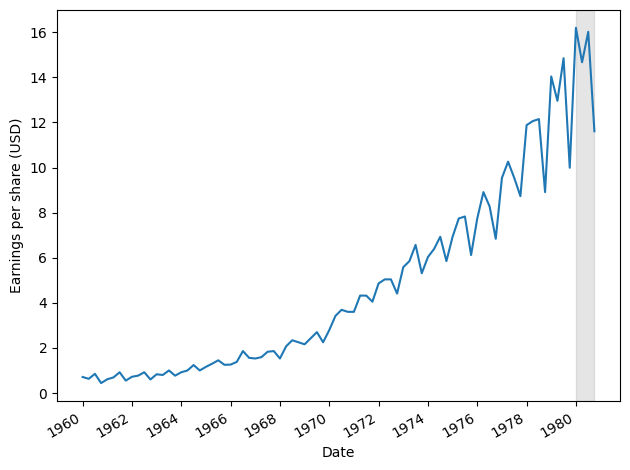

In [6]:
fig, ax = plt.subplots()

ax.plot(df.date, df.data)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()

In [7]:
# optimize_ARIMA 함수 정의. 

from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX

#함수: 각 (p,q)조합과 그에 해당하는 AIC를 저장할 빈 목록을 초기화. 그 다음 각 (p,q) 조합에 대한 ARMA(p,q)모델을 데이터 피팅.
# AIC 계산하고 그 결과 저장. 그 다음 DataFrame을 생성하고, AIC 값이 낮을수록 더 좋은 모델이므로 AIC 값을 기준으로 오름차순으로 정렬.
def optimize_ARIMA(endog: Union[pd.Series, list], order_list: list, d: int) -> pd.DataFrame: #endog: 관측된 시계열 데이터
    # 고유 (p,q) 조합들의 목록, 적분 차수 d를 입력받는다. 
    results = [] 

    for order in tqdm_notebook(order_list): #모든 (p,q) 조합의 목록에 대해 for 루프. tqdm_notebook을 통해 진행률 표시.
        try:
            model = SARIMAX(endog, order = (order[0], d, order[1]),
                            simple_differencing=False).fit(disp = False) #SARIMAX 함수를 사용해 ARMA(p,d,q) 모델 피팅. 
                            #차분이 되지 않도록 simple_differencing을 False.
                            # 콘솔에 상태 메시지 안 나오도록 disp = False.
        except:
            continue

        aic = model.aic #모델의 aic 계산.
        results.append([order,aic]) #결과 목록에 (p,q) 조합과 AIC를 튜플로 추가.

    result_df = pd.DataFrame(results) #(p,q) 조합과 AIC를 DataFrame에 저장
    result_df.columns = ['(p,q)', 'AIC'] #DataFrame의 열에 레이블 지정

    # ascending order as lower AIC is better
    result_df = result_df.sort_values(by = 'AIC', ascending = True).reset_index(drop = True) #AIC값을 기준으로 오름차순 정렬.

    return result_df

이제 함수를 사용해 차수 p와 q로 가능한 값의 목록을 정의. 여기서는 0-3 값을 시도하고, 고유한 (p,q) 조합의 목록을 생성.

In [ ]:
from itertools import product

ps = range(0,4,1)
qs = range(0,4,1)

d = 2 # 수열이 정상적이 되려면 두 번 차분해야 하기에, d = 2

order_list = list(product(ps,qs)) #(p,q)의 모든 고유 조합을 포함하는 목록목록

d는 범위가 아니라 구체적인 값. 차분하는 횟수를 우리는 미리 알기 때문.  

그리고 AIC를 사용해 모델을 비교하려면 d는 일정해야 함. d가 변동되면 AIC값 계산에 사용되는 가능도 함수가 변경되기에 AIC를 기준으로 모델을 비교하는 것은 더 이상 유효하지 않음.  

이제 훈련 집합을 사용해 optimze_ARIMA 함수 실행. 가장 낮은 AIC를 가진 모델이 맨 위에 있게 반환.

In [10]:
train = df.data[:-4]

result_df = optimize_ARIMA(train, order_list, d)
result_df 

/var/folders/90/n8q4mqbs1rx3l__g3k8mybj80000gq/T/ipykernel_49491/1026345783.py:13: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list): #모든 (p,q) 조합의 목록에 대해 for 루프. tqdm_notebook을 통해 진행률 표시.


  0%|          | 0/16 [00:00<?, ?it/s]

/Users/michael.cho/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/michael.cho/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/michael.cho/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/michael.cho/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA par

,"(p,q)",AIC
0,"(3, 3)",115.267148
1,"(3, 1)",115.624981
2,"(3, 2)",115.672007
3,"(3, 0)",154.430633
4,"(0, 3)",194.654716
5,"(0, 2)",209.274579
6,"(2, 3)",220.667046
7,"(1, 3)",228.267775
8,"(1, 2)",228.935789
9,"(2, 2)",229.974663


결과, ARIMA(3,2,3) 모델이 가장 적합한 것으로 보임. 이제 잔차를 조사해 모델의 유효성 평가.  

/Users/michael.cho/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/michael.cho/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


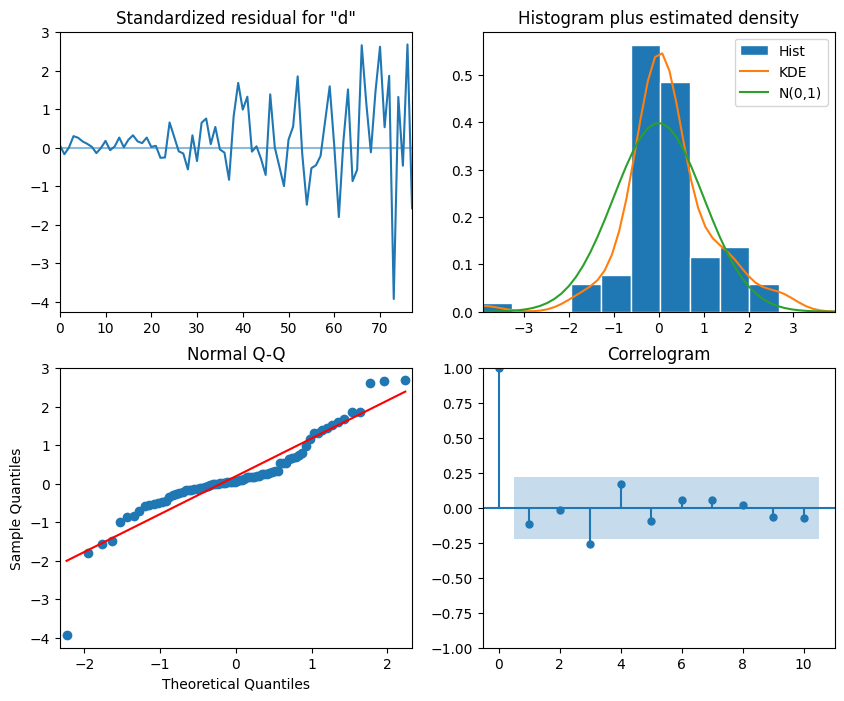

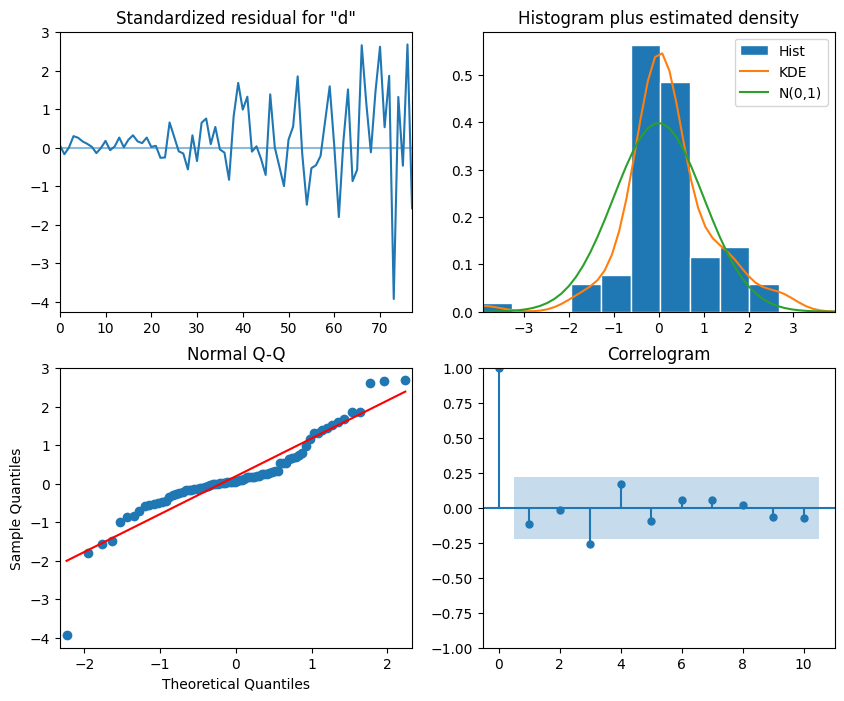

In [11]:
model = SARIMAX(train, order = (3,2,3), simple_differencing= False)
model_fit = model.fit(disp = False)

model_fit.plot_diagnostics(figsize=(10,8))

도식 해석:
- 좌측 상단: 시간 경과에 따른 잔차
    - 잔차에 추세는 없지만 분산이 일정하지 않음 --> 백색소음과는 약간의 차이가 있음.
- 우측 상단: 잔차의 분포
    - 정규분포에 상당히 가까움. 
- 좌측 하단: Q-Q 도식
    - 잔차의 분포가 정규분포에 가깝게 상당히 직선적인 선.
- 우측 하단: 상관관계도
    - 지연 3에서 계수 유의. 하지만 그 앞에서 유의한 자기상관 관계가 없기에 우연에 의한 것으로 추정. 

따라서, 정상적 관점에서 보면 잔차는 백색소음에 가까운 것으로 보임 --> 모델의 오차가 무작위적이라는 뜻이므로 좋은 징조.

Ljung Box Test를 통한 정량적 관점에서 잔차 평가  
- 처음 10개의 지연에 대해 테스트를 적용하고 p-값을 조사
- 모든 p-val이 0.05보다 크면 귀무가설을 기각할 수 없으므로 잔차가 백색소음과 마찬가지로 상관관계가 없다고 결론.

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = model_fit.resid

lb_df = acorr_ljungbox(residuals, np.arange(1, 11, 1))
pvalue = lb_df['lb_pvalue']

lb_df

,lb_stat,lb_pvalue
1,1.672081,0.195980
2,1.674404,0.432920
3,7.295059,0.063065
4,9.260367,0.054911
5,9.884035,0.078589
6,10.125813,0.119453
7,10.373837,0.168360
8,10.406096,0.237672
9,10.746787,0.293466
10,11.186100,0.343204


모델 잔차의 첫 10개의 지연에 대해 테스트 진행하면 모두 0.05보다 큰 p-val 반환. 

ARIMA(3,2,3) 모델은 모든 검사 통과했으니 예측 사용 가능. 테스트 집합은 80년에 보고된 4개의 분기별 주당순이익에 해당하는 마지막 4개의 데이터 요소. 모델의 평가 기준으로는 단순한 계절적 방법 사용.  
- 1979년 1분기 주당순이익을 1980년 1분기의 주당순이익에 대한 예측으로 사용. 
- 그 다음 1979년 2분기의 주당순이익을 1980년 2분기의 주당순이익에 대한 예측으로 사용하는 식.

In [14]:
#baseline
test = df.iloc[-4:] # 테스트 집합은 마지막 4개의 데이터 요소에 해당.

test['naive_seasonal'] = df['data'].iloc[76:80].values # 1979년에 보고된 분기별 주당순이익을 
# 1980년에 대한 예측으로 사용하는 단순한 계절적 예측 방법을 구현.

/var/folders/90/n8q4mqbs1rx3l__g3k8mybj80000gq/T/ipykernel_49491/912025933.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['naive_seasonal'] = df['data'].iloc[76:80].values # 1979년에 보고된 분기별 주당순이익을


이제 ARIMA(3,2,3)모델을 사용해 예측 수행. 그 결과는 ARIMA_pred 열에 저장.

In [16]:
ARIMA_pred = model_fit.get_prediction(80, 83).predicted_mean #1980년에 대한 예측값을 가져옴. 

test['ARIMA_pred'] = ARIMA_pred
test

/var/folders/90/n8q4mqbs1rx3l__g3k8mybj80000gq/T/ipykernel_49491/2355165780.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['ARIMA_pred'] = ARIMA_pred


,date,data,naive_seasonal,ARIMA_pred
80,1980-01-01,16.20,14.04,15.858831
81,1980-04-01,14.67,12.96,14.380432
82,1980-07-02,16.02,14.85,16.365355
83,1980-10-01,11.61,9.99,11.681111


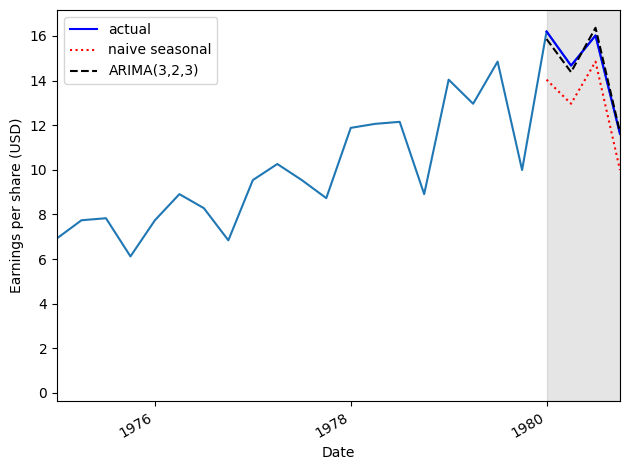

In [17]:
fig, ax = plt.subplots()

ax.plot(df['date'], df['data'])
ax.plot(test['data'], 'b-', label='actual')
ax.plot(test['naive_seasonal'], 'r:', label='naive seasonal')
ax.plot(test['ARIMA_pred'], 'k--', label='ARIMA(3,2,3)')

ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
ax.set_xlim(60, 83)

fig.autofmt_xdate()
plt.tight_layout()

도식 해석:
- 단순한 계절적 예측은 점선. ARIMA(3,2,3) 예측은 파선.  

평균절대백분율오차를 측정해 오차를 정량화 하고 각 예측 방법에 대한 지표를 막대형 차트에 표시.

In [19]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_naive_seasonal = mape(test['data'], test['naive_seasonal']) # 단순한 계절적 방법에 대한 MAPE 계산
mape_ARIMA = mape(test['data'], test['ARIMA_pred']) # ARIMA(3,2,3)에 대한 MAPE를 계산

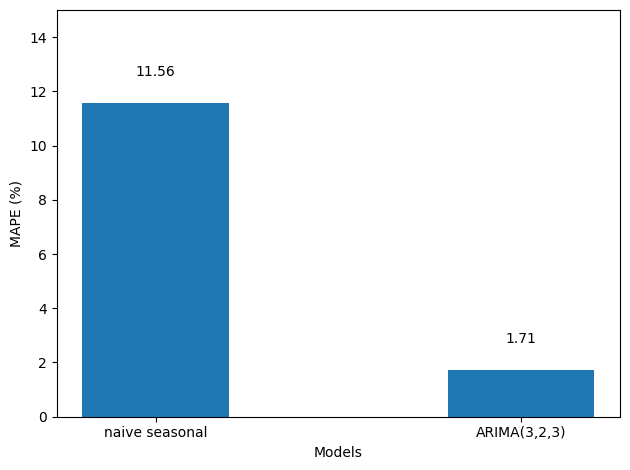

In [23]:
fig, ax = plt.subplots()

x = ['naive seasonal', 'ARIMA(3,2,3)']
y = [mape_naive_seasonal, mape_ARIMA]

ax.bar(x, y, width = 0.4)
ax.set_xlabel('Models')
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 15)

for index, value in enumerate(y):
    plt.text(x = index, y=value + 1, s = str(round(value, 2)), ha = 'center')
    # +1은 글씨의 높이; 값에 영향을 주는것이 아님

plt.tight_layout()

naive seasonal의 MAPE는 11.56%인 반면, ARIMA(3,2,3) 모델의 MAPE는 1.71%로, 벤치마크값의 약 1/5 수준. 즉, 예측값이 실젯값에서 평균적으로 1.71% 정도 차이를 보인다. ARIMA(3,2,3)이 훨씬 좋은 모델. 